# Fraud Detection Analytics - Exploratory Data Analysis

This notebook focuses on visualization and business insights from the cleaned fraud dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("fraud_cleaned.csv")

df.head()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,1.0,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,3.0,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,3.0,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,99.482201,3.0,0.0,4.0,38.733609,8.0,17.321496,2.0,100.000000,0.0,1.0,5.535335,1


## Fraud Distribution

Analyze the distribution of legitimate and fraudulent transactions.

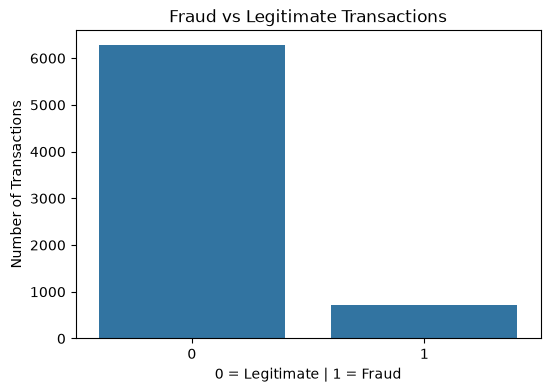

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_fraud', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('0 = Legitimate | 1 = Fraud')
plt.ylabel('Number of Transactions')

plt.show()

### Observation

- Legitimate transactions significantly outnumber fraudulent transactions.
- Fraudulent transactions represent only a small portion of total transactions.
- This indicates class imbalance, which is common in fraud detection datasets.

## Transaction Amount Distribution by Fraud Status

Analyze how transaction amounts are distributed for legitimate and fraudulent transactions.

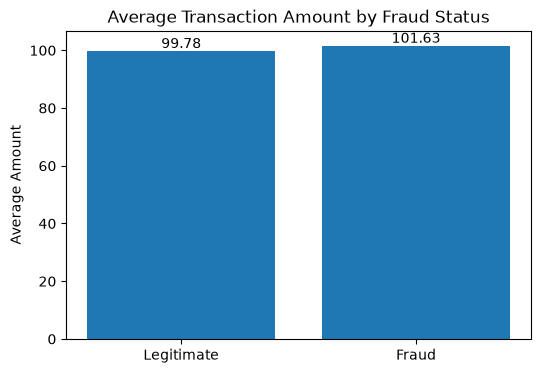

In [16]:
fraud_amount = df.groupby('is_fraud')['transaction_amount'].mean()

fraud_amount.plot(kind='bar')

plt.title('Average Transaction Amount by Fraud Status')
plt.xlabel('0 = Legitimate | 1 = Fraud')
plt.ylabel('Average Transaction Amount')

plt.show()

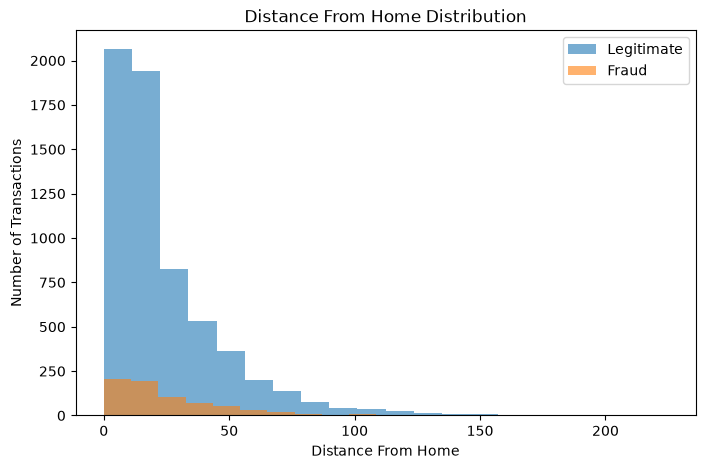

In [24]:
distance_avg = df.groupby('is_fraud')['distance_from_home'].mean()

plt.figure(figsize=(6,4))

plt.scatter(
    ['Legitimate', 'Fraud'],
    distance_avg.values,
    s=300
)

for i, value in enumerate(distance_avg.values):
    plt.text(
        i,
        value + 0.5,
        f'{value:.2f}',
        ha='center'
    )

plt.title('Average Distance From Home')
plt.ylabel('Distance')

plt.show()

### Observation

- Most transactions occur close to the customer's home location.
- Fraudulent transactions show a slightly higher average distance from home compared to legitimate transactions.
- As distance increases, the number of transactions decreases for both groups.
- The wider spread of fraudulent transactions suggests that unusual transaction locations may be associated with suspicious activity.
- Distance from home was identified as one of the most important features in the Random Forest model, indicating its value for fraud detection.

## Correlation Analysis

Identify which variables have the strongest relationship with fraud.

In [29]:
correlation = df.corr(numeric_only=True)

correlation['is_fraud'].sort_values(ascending=False)

is_fraud                1.000000
distance_from_home      0.046802
is_first_transaction    0.012860
transaction_amount      0.011939
store_type              0.011919
prev_transactions       0.004841
is_weekend              0.000404
network_quality        -0.000947
customer_age           -0.010556
hour_of_day            -0.013918
velocity_score         -0.021778
num_items              -0.022055
device_type            -0.036652
Name: is_fraud, dtype: float64

## Correlation Heatmap

Visualize relationships between numerical variables and identify factors associated with fraud.

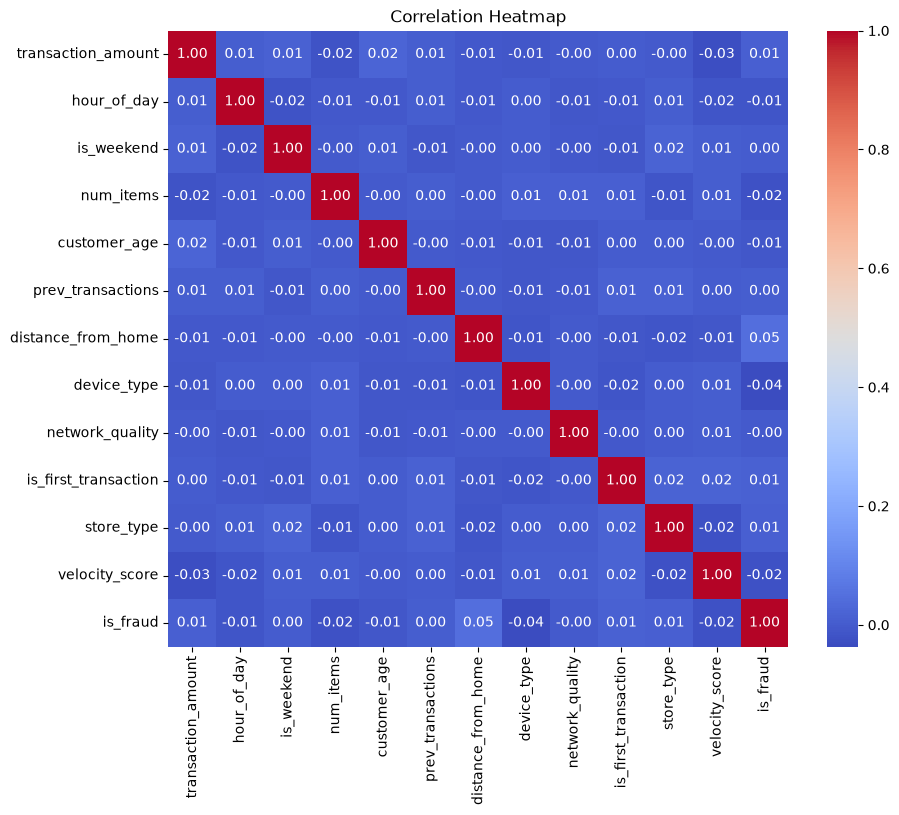

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

- Most variables show weak correlations with fraud.
- Distance from home exhibits the strongest positive relationship with fraud.
- Transaction amount and first transaction status show slight positive associations.
- No single variable strongly predicts fraudulent activity.

# Machine Learning

Build predictive models to classify transactions as legitimate or fraudulent.

## Logistic Regression

Build a baseline classification model for fraud prediction.

In [34]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


### Model Evaluation

In [37]:
from sklearn.metrics import classification_report



print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1256
           1       0.00      0.00      0.00       144

    accuracy                           0.90      1400
   macro avg       0.45      0.50      0.47      1400
weighted avg       0.80      0.90      0.85      1400



### Observation

- Logistic Regression achieved 90% accuracy.
- However, the model failed to identify any fraudulent transactions.
- This occurred due to class imbalance in the dataset.
- Accuracy alone is not a reliable metric for fraud detection.

## Random Forest Model

Build a Random Forest classifier with balanced class weights to improve fraud detection performance.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [39]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1256
           1       0.50      0.02      0.04       144

    accuracy                           0.90      1400
   macro avg       0.70      0.51      0.49      1400
weighted avg       0.86      0.90      0.85      1400



### Observation

- Random Forest performed better than Logistic Regression.
- The model was able to identify some fraudulent transactions.
- However, fraud recall remained very low.
- The weak feature relationships observed during EDA likely limited model performance.
- Additional feature engineering or advanced techniques would be required for stronger fraud detection.

## Confusion Matrix

Visualize model predictions against actual outcomes.

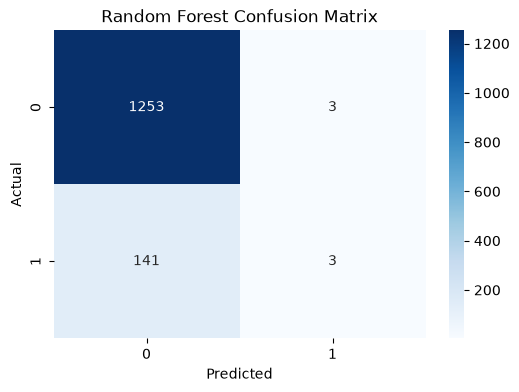

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Feature Importance

Identify which variables contributed most to model predictions.

In [41]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

transaction_amount      0.153938
distance_from_home      0.150422
velocity_score          0.149830
network_quality         0.139947
customer_age            0.131250
prev_transactions       0.092843
num_items               0.070725
hour_of_day             0.032791
device_type             0.030241
store_type              0.021553
is_weekend              0.013825
is_first_transaction    0.012635
dtype: float64

## Feature Importance Analysis

Identify the variables that contributed most to fraud prediction.

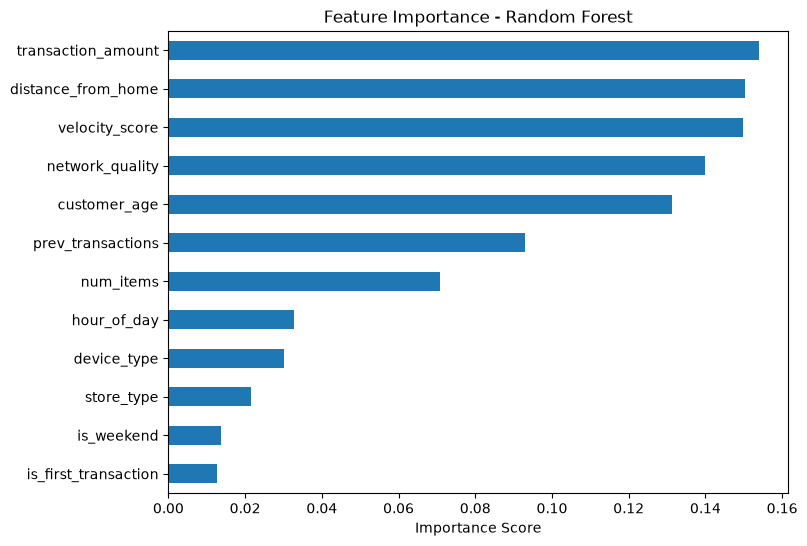

In [42]:
feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')

plt.show()

### Observation

- Transaction amount was the most important feature for fraud prediction.
- Distance from home and velocity score also contributed significantly.
- Network quality and customer age showed moderate influence.
- Weekend activity and first transaction status had the lowest impact.

# Business Recommendations

### Recommendations

- Monitor unusually high transaction amounts.
- Flag transactions occurring far from a customer's typical location.
- Combine multiple risk indicators rather than relying on a single variable.
- Implement machine learning monitoring systems for real-time fraud detection.
- Continuously retrain models as transaction patterns evolve.

# Conclusion

This project analyzed 7,000 financial transactions to identify fraud patterns.

Key findings include:

- Fraud represented approximately 10% of all transactions.
- Distance from home showed the strongest relationship with fraudulent activity.
- Transaction amount emerged as the most important predictor in the Random Forest model.
- Logistic Regression struggled due to class imbalance.
- Random Forest improved fraud detection but further optimization would be required for production use.

This project demonstrates data cleaning, exploratory data analysis, feature evaluation, machine learning, and business recommendation development using Python.